# **training a CNN model on the CIFAR-10 dataset**

## CNN class definition:

In [ ]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(
            kernel_size=2, 
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x): # initial shape of x: Batch × 3 × 32 × 32
        x = self.conv1(x) # Batch × 32 × 32 × 32
        x = self.relu(x)
        
        x = self.pool(x) # Batch × 32 × 16 × 16

        x = self.conv2(x) # Batch × 64 × 16 × 16
        x = self.relu(x)

        x = self.pool(x) # Batch × 64 × 8 × 8

        x = self.flatten(x) # Batch × 4096

        x = self.fc1(x) # Batch × 512
        x = self.relu(x)

        x = self.fc2(x) # Batch × 10
        return x

# training for one epoch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from models.cnn import CNN
# from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = CNN().to(device)
# model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

best_accuracy = 0.0
num_epochs = 1
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #evaluate
    model.eval()

    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, dim=1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_accuracy = 100 * test_correct / test_total

    # if test_accuracy > best_accuracy:
    #     best_accuracy = test_accuracy
    #     torch.save(
    #         model.state_dict(),
    #         "saved_models/mlp.pth"
    #     ) 
    #     print("Model saved to saved_models/cnn.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Test Acc: {test_accuracy:.2f}%"
    )  

print(f"Best Test Accuracy: {best_accuracy:.2f}%")

## output of CNN:
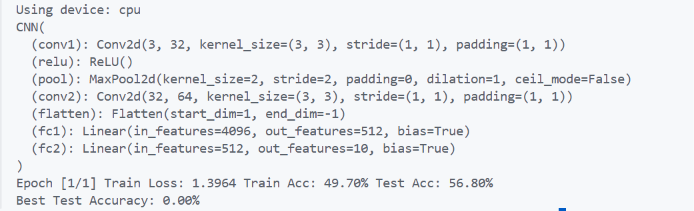
<br><br>
## output of MLP for comparision:
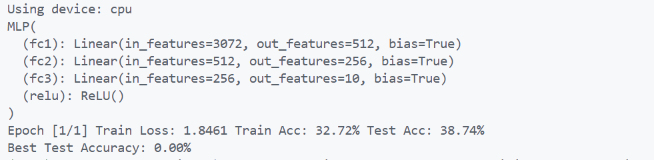

# training for  multiple epochs

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from models.cnn import CNN
# from models.mlp import MLP
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = CNN().to(device)
# model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

best_accuracy = 0.0
num_epochs = 10
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #evaluate
    model.eval()

    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, dim=1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_accuracy = 100 * test_correct / test_total

    # if test_accuracy > best_accuracy:
    #     best_accuracy = test_accuracy
    #     torch.save(
    #         model.state_dict(),
    #         "saved_models/mlp.pth"
    #     ) 
    #     print("Model saved to saved_models/mlp.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Test Acc: {test_accuracy:.2f}%"
    )  

print(f"Best Test Accuracy: {best_accuracy:.2f}%")

## output of CNN:
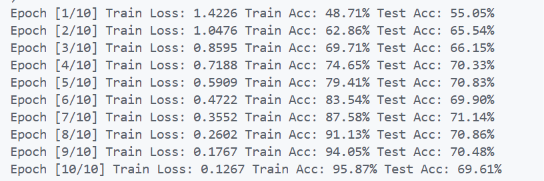
<br><br>

## output of MLP for comparision: 

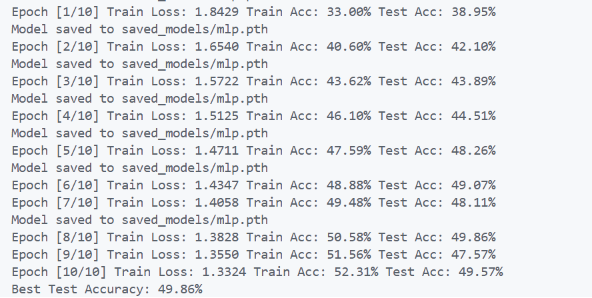


# visualization of the loss curve and accuracy curve

In [ ]:
# same code as visualization for MLP
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from models.cnn import CNN
from utils import get_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_dataloaders(batch_size=64)
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)
print(model)

train_losses = []
train_accuracies = []
test_accuracies = []

best_accuracy = 0.0
num_epochs = 10
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, dim=1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    #evaluate
    model.eval()

    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, dim=1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_accuracy = 100 * test_correct / test_total

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        torch.save(
            model.state_dict(),
            "saved_models/cnn.pth"
        ) 
        print("Model saved to saved_models/mlp.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Test Acc: {test_accuracy:.2f}%"
    )  

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

print(f"Best Test Accuracy: {best_accuracy:.2f}%")

epochs = range(1, num_epochs + 1)

# plot for loss curve
plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, marker="o")
plt.title("Training Loss (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# plot for accuracy curve
plt.figure(figsize=(8,5))
plt.plot(epochs, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(epochs, test_accuracies, marker="o", label="Test Accuracy")
plt.title("Accuracy (CNN)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

## training loss:
### CNN:
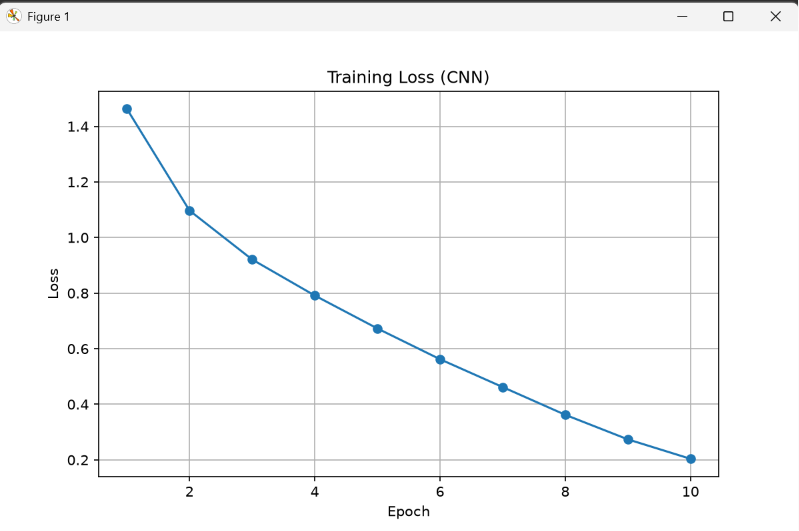
<br><br>
### MLP:
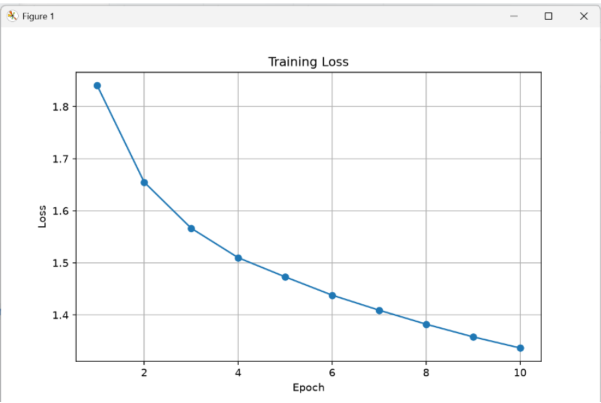
<br><br><br>
## accuracy:
### CNN:
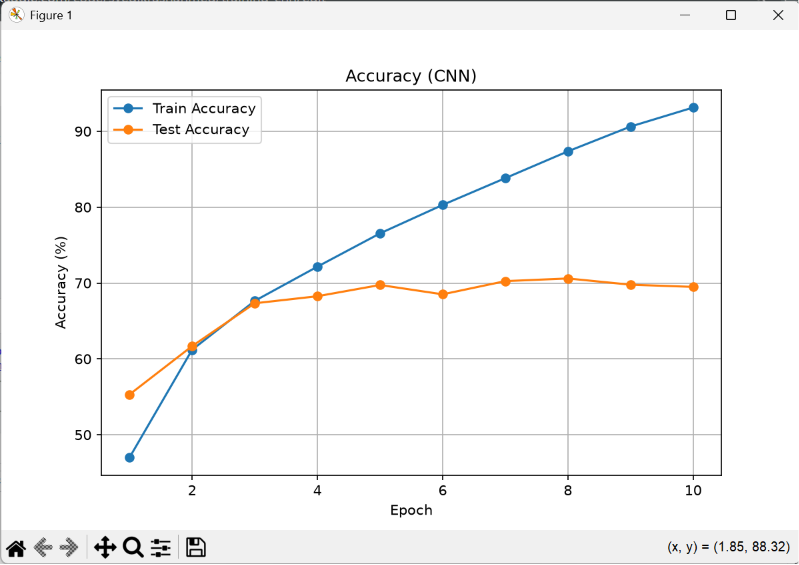
<br><br>
### MLP:
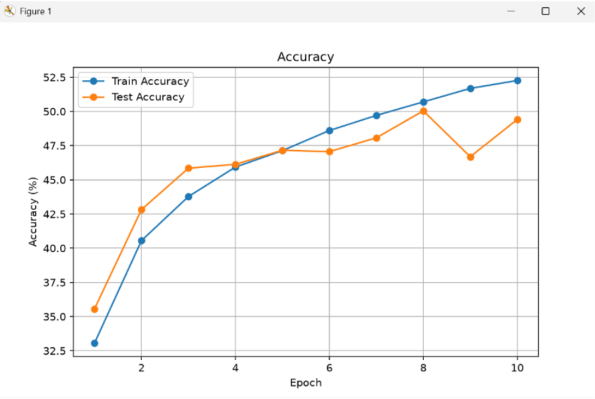
<br><br>

- the loss curves have the same shape, but the lowest loss for MLP is 1.33, and the lowest loss for CNN is 0.12
- the accuracy curves are different, as there is clear overfitting in CNN, where the training accuaracy is > 90, while the test accuracy is 70, meaning the model is memorising the training data

# visualization of the confusion matrix and prediction visualization

In [ ]:
import torch

from models.mlp import MLP
# from models.cnn import CNN
from utils import get_dataloaders

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

_, test_loader = get_dataloaders(batch_size=64)
model = MLP().to(device)
# model = CNN().to(device)
model.load_state_dict(
    # torch.load("saved_models/cnn.pth", map_location=device)
    torch.load("saved_models/mlp.pth", map_location=device)
)
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,7))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()

plt.show()

# prediction visualization
plt.figure(figsize=(12,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i].permute(1,2,0)

    plt.imshow(img)

    plt.title(
        f"P: {classes[predicted[i]]}\nT: {classes[labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

## Confusion Matrix:
### MLP:
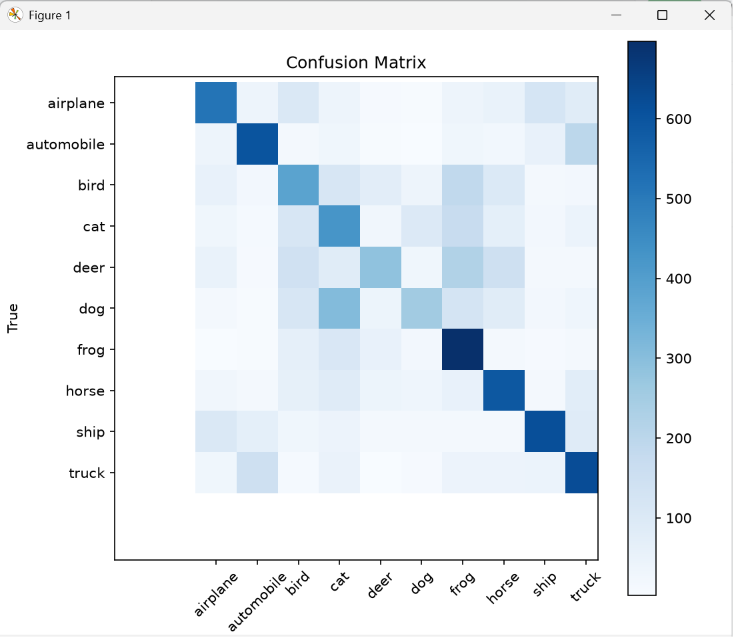
<br><br>
### CNN:
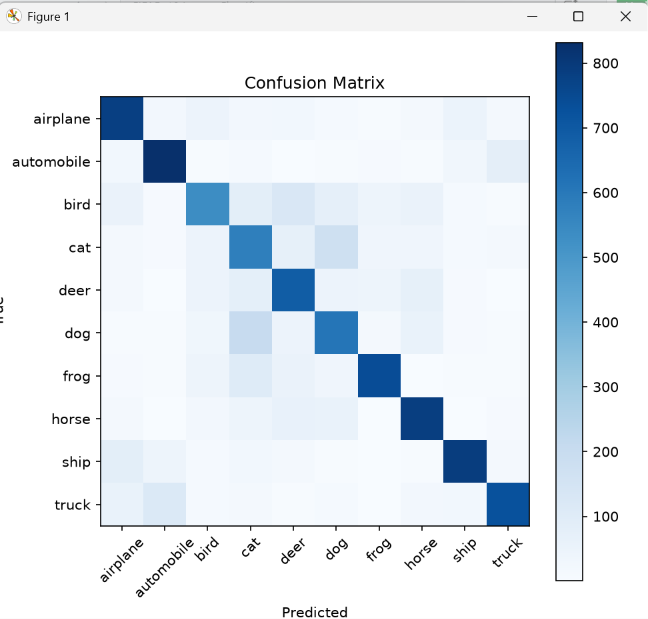

## Visualization Prediction:
### MLP:
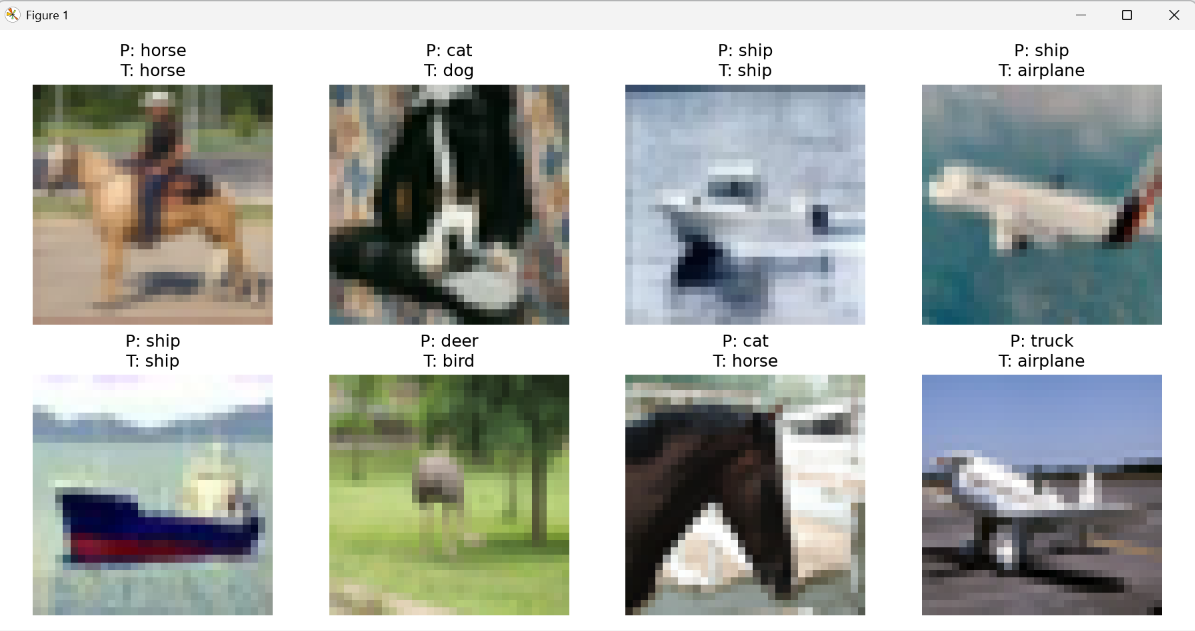
<br><br>
### CNN:
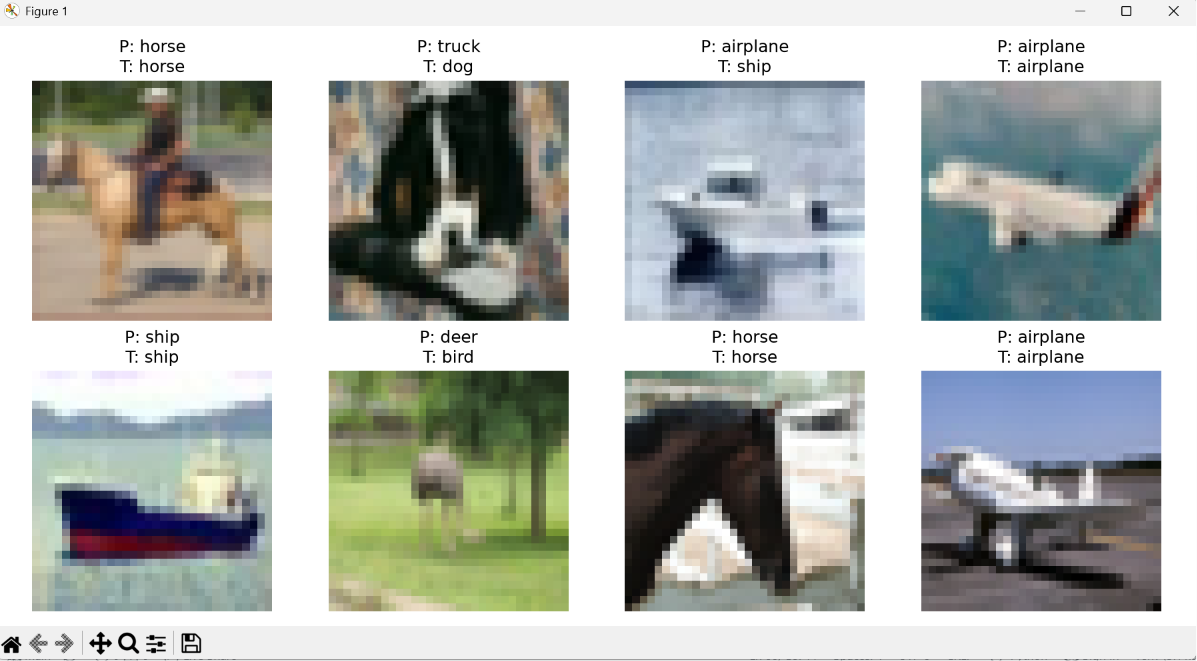